[warn] Large: tag_acc (0.9908) != pos_acc (0.9909). They are not interchangeable here — worth investigating.
[warn] Large (old): tag_acc (0.9771) != pos_acc (0.9872). They are not interchangeable here — worth investigating.
[warn] GPT-4: reports only one of tag_acc / pos_acc — the equality assumption is untested here.
[warn] Medium: tag_acc (0.9861) != pos_acc (0.9856). They are not interchangeable here — worth investigating.
[warn] Medium (old): tag_acc (0.9691) != pos_acc (0.9803). They are not interchangeable here — worth investigating.
[warn] spaCy trf: reports only one of tag_acc / pos_acc — the equality assumption is untested here.
[warn] Small: tag_acc (0.9806) != pos_acc (0.9786). They are not interchangeable here — worth investigating.
[warn] Small (old): tag_acc (0.9645) != pos_acc (0.9754). They are not interchangeable here — worth investigating.
[warn] Tiny: tag_acc (0.9685) != pos_acc (0.9674). They are not interchangeable here — worth investigating.
[warn] spaCy lg: repor

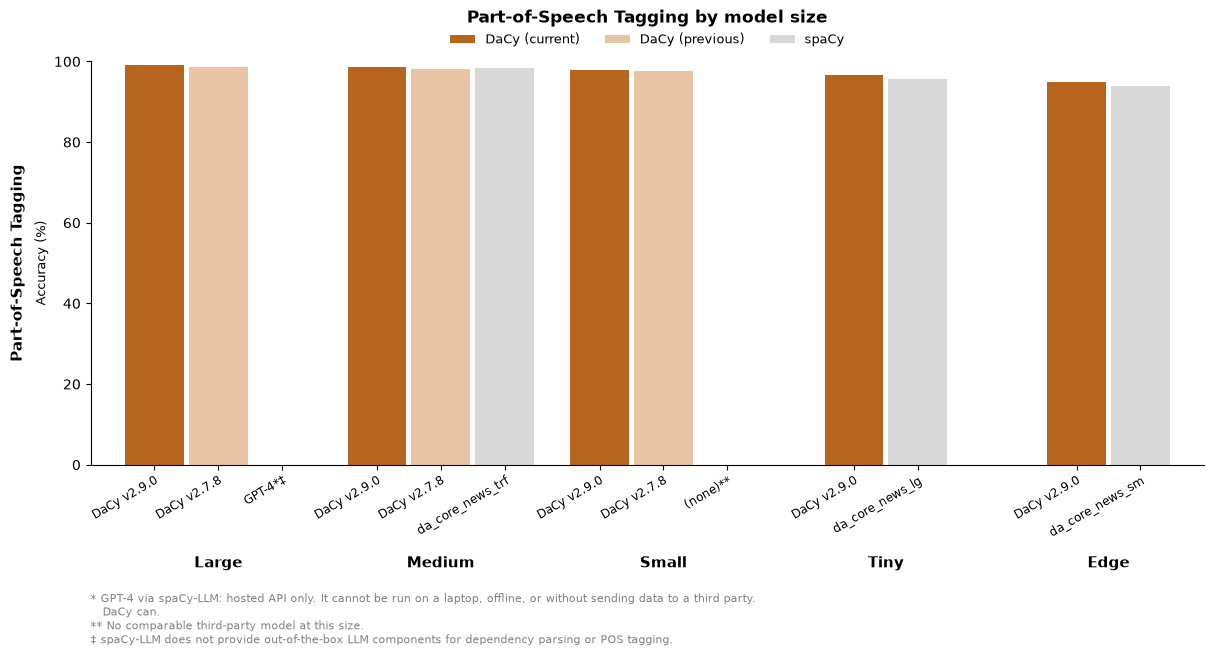

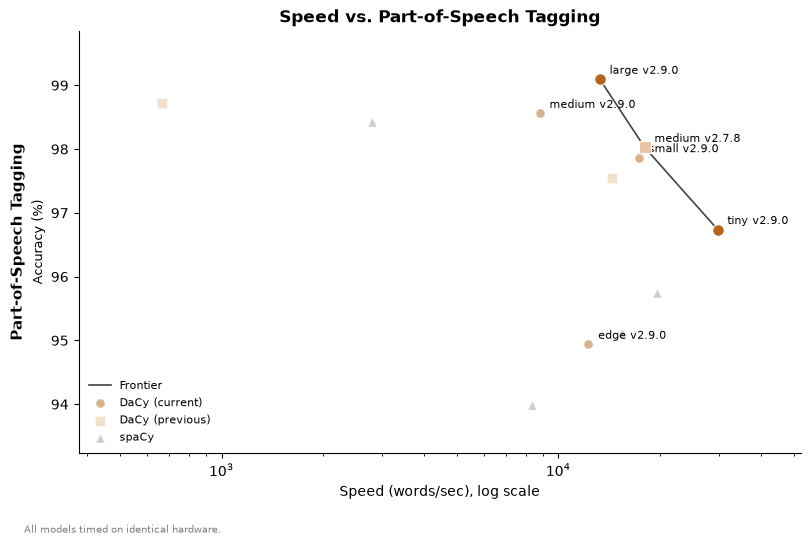

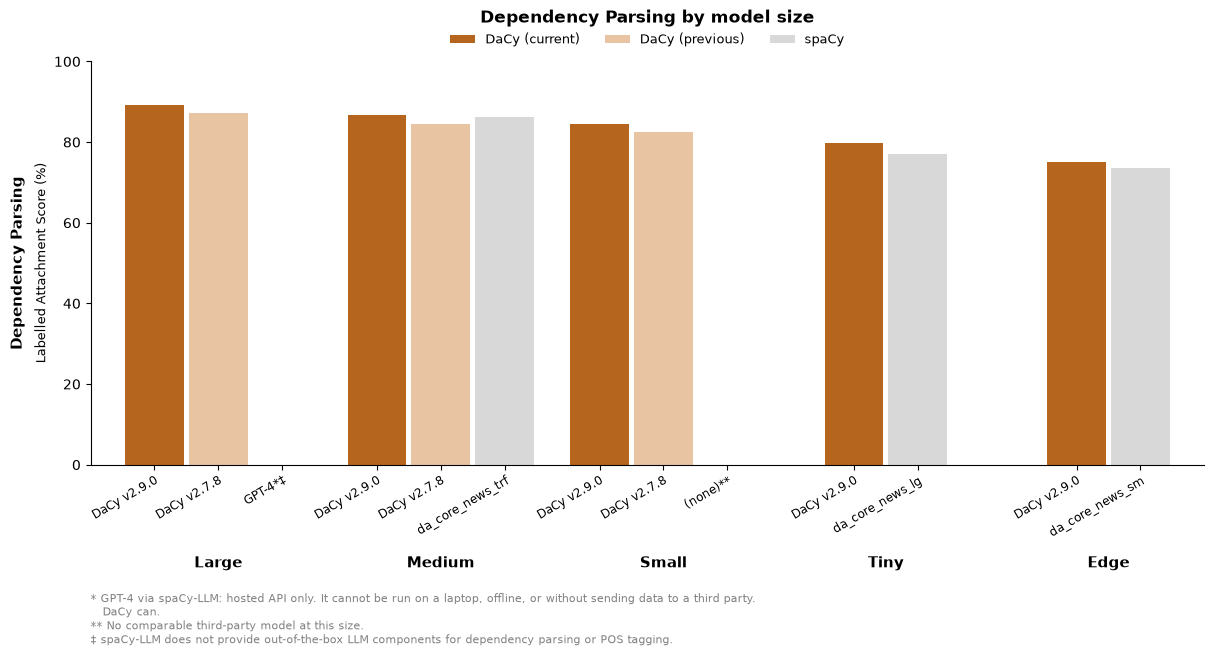

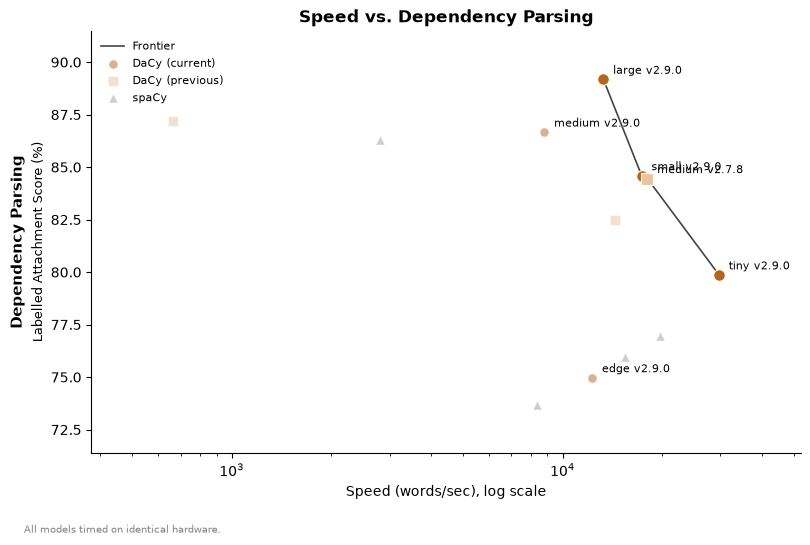

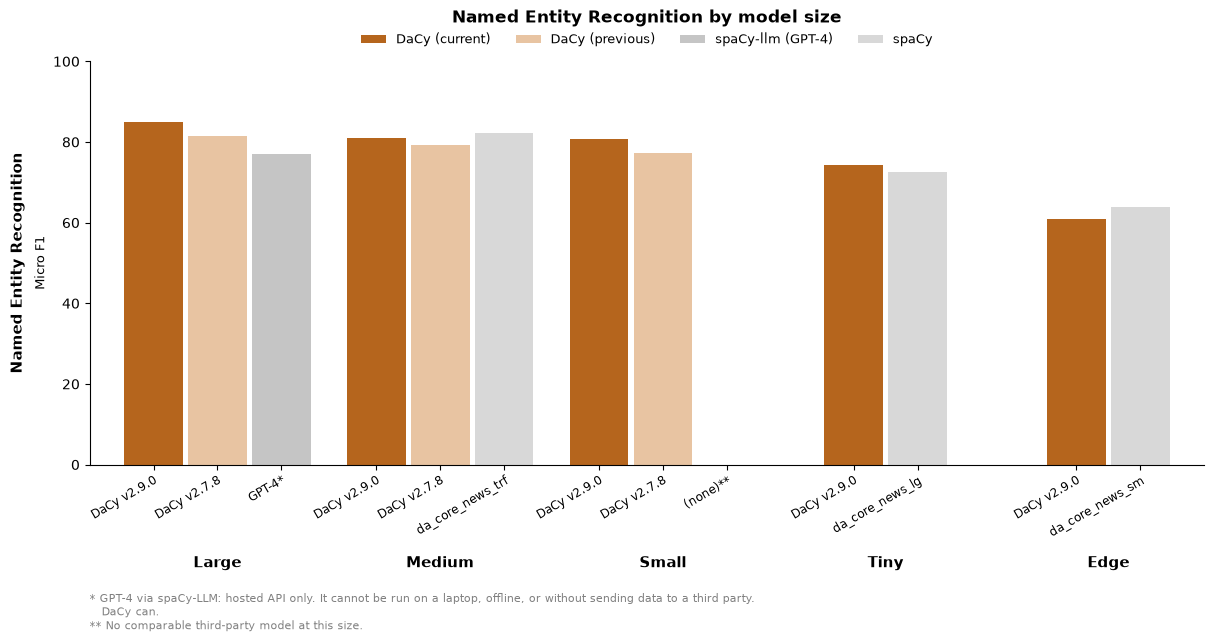

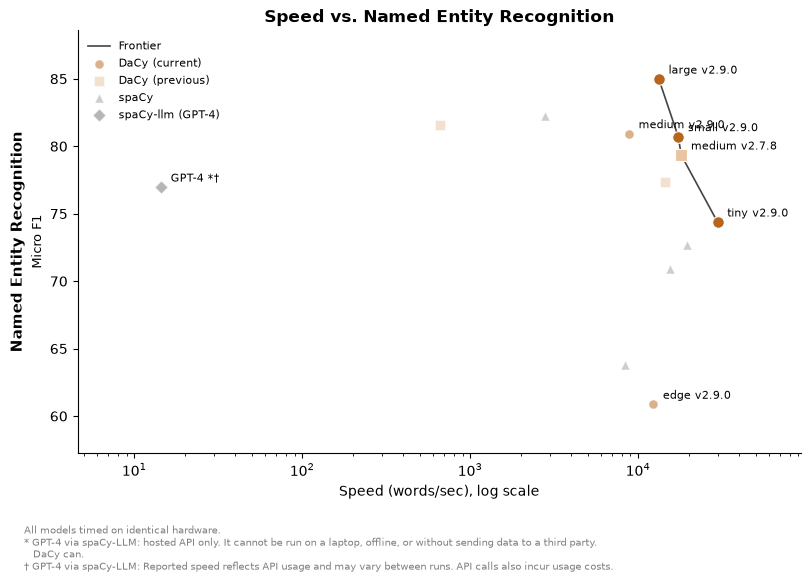

In [ ]:
"""
Visualize DaCy model metrics from JSON files.

Three headline metrics (POS_ACC, ENTS_F, DEP_LAS) each get a grouped bar plot
(x = size tier, one labelled bar per model) and a speed/performance pareto plot.
Every metric, including the ones without plots, appears in the exported markdown
table.

Grouping is by *deployment tier*, not by provider: each cluster holds the current
DaCy model, its predecessor, and whichever third-party model is the realistic
alternative at that size. Every bar carries its own tick label, so the figure
names the model rather than making the reader decode it from the legend; the
tier heading sits underneath as a second level. Colour is redundant encoding.

Axes are named by task and metric rather than by the raw JSON key: see
AXIS_LABELS.

Edit MODELS to swap models in/out; edit the `plot` flag in METRICS to change
which metrics get figures.
"""

import json
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

METRICS_DIR = Path("/work/training_practice/ddt_dane_cdt_project/metrics")
OUT_DIR = Path(".")

CUR, OLD = "v2.9.0", "v2.7.8"


def model(file, tier, provider, version, label, full=None, **notes):
    """Build one MODELS entry; `full` defaults to the short label."""
    return {
        "file": file,
        "tier": tier,
        "provider": provider,
        "version": version,
        "label": label,
        "full": label if full is None else full,
        **notes,
    }


MODELS = {
    # Large
    "Large": model("dacy_large_trf.json", "Large", "DaCy", "current",
                   f"DaCy {CUR}", f"DaCy large {CUR}"),
    "Large (old)": model("dacy_large_old.json", "Large", "DaCy", "old",
                         f"DaCy {OLD}", f"DaCy large {OLD}"),
    "GPT-4": model(
        "llm-ner.json", "Large", "spaCy", "llm",
        "GPT-4", "GPT-4 via spaCy-LLM",
        deploy_note=(
            "hosted API only. It cannot be run on a laptop, offline, or without "
            "sending data to a third party. DaCy can."
        ),
        speed_note=(
            "Reported speed reflects API usage and may vary between runs. "
            "API calls also incur usage costs."
        ),
    ),

    # Medium
    "Medium": model("dacy_medium_trf.json", "Medium", "DaCy", "current",
                    f"DaCy {CUR}", f"DaCy medium {CUR}"),
    "Medium (old)": model("dacy_medium_old.json", "Medium", "DaCy", "old",
                          f"DaCy {OLD}", f"DaCy medium {OLD}"),
    "spaCy trf": model("spacy_da_core_news_trf.json", "Medium", "spaCy", "current",
                       "da_core_news_trf"),

    # Small
    "Small": model("dacy_small_trf.json", "Small", "DaCy", "current",
                   f"DaCy {CUR}", f"DaCy small {CUR}"),
    "Small (old)": model("dacy_small_old.json", "Small", "DaCy", "old",
                         f"DaCy {OLD}", f"DaCy small {OLD}"),

    # Tiny
    "Tiny": model("dacy_tiny.json", "Tiny", "DaCy", "current",
                  f"DaCy {CUR}", f"DaCy tiny {CUR}"),
    "spaCy lg": model("spacy_da_core_news_lg.json", "Tiny", "spaCy", "current",
                      "da_core_news_lg"),

    # Edge
    "Edge": model("dacy_edge.json", "Edge", "DaCy", "current",
                  f"DaCy {CUR}", f"DaCy edge {CUR}"),
    "spaCy sm": model("spacy_da_core_news_sm.json", "Edge", "spaCy", "current",
                      "da_core_news_sm"),

    # Kept in the table/Pareto plots, excluded from tiered bar plots.
    "spaCy md": model("spacy_da_core_news_md.json", None, "spaCy", "current",
                      "da_core_news_md"),
}

# (provider, version) -> style. Same hue at different weights reads as
# "same model, older"; grey reads as "reference", not "worse".
STYLES = {
    ("DaCy",  "current"): {"label": "DaCy (current)",  "color": "#B5651D", "text": "white",   "marker": "o"},
    ("DaCy",  "old"):     {"label": "DaCy (previous)", "color": "#E8C4A2", "text": "#5A3A1A", "marker": "s"},
    ("spaCy", "current"): {"label": "spaCy",           "color": "#9E9E9E", "text": "white",   "marker": "^"},
    ("spaCy", "llm"):     {"label": "spaCy-llm (GPT-4)", "color": "#6E6E6E", "text": "white", "marker": "D"},
}
FRONTIER_COLOR = "#444444"
BAR_SPAN = 0.86      # width of one tier's cluster, in x units
BAR_ALPHA_OTHER = 0.4

# A declared lineup gap is an empty labelled slot, not a zero-height bar.
TIER_NOTES = {
    "Small": {"label": "(none)", "note": "No comparable third-party model at this size."},
}

MARK_DEPLOY = "*"    # caveat about running the model — on every plot
MARK_TIER = "**"     # missing competitor
MARK_UNSUPPORTED = "‡"
MARK_SPEED = "†"     # caveat about how speed was measured — pareto only
MIN_Y_SPAN = 5.0     # points on the score axis
NOTE_WRAP = 120      # characters, so long footnotes stay inside the figure

LLM_UNSUPPORTED = {
    "POS_ACC",
    "DEP_LAS",
}

HARDWARE_NOTE = "All models timed on identical hardware."

LLM_UNSUPPORTED_NOTE = (
    "spaCy-LLM does not provide out-of-the-box LLM components "
    "for dependency parsing or POS tagging."
)

# key, display label, task, gets_plot
# tag_acc is deliberately absent: identical to pos_acc for Danish. Verified at
# load time by check_tag_pos() rather than assumed.
METRICS = [
    ("token_acc",     "TOKEN_ACC",     "Tokenization",          False),
    ("token_f",       "TOKEN_F",       "Tokenization",          False),
    ("pos_acc",       "POS_ACC",       "Tagging & Morphology",  True),
    ("morph_acc",     "MORPH_ACC",     "Tagging & Morphology",  False),
    ("morph_micro_f", "MORPH_MICRO_F", "Tagging & Morphology",  False),
    ("lemma_acc",     "LEMMA_ACC",     "Tagging & Morphology",  False),
    ("sents_f",       "SENTS_F",       "Sentence Segmentation", False),
    ("dep_uas",       "DEP_UAS",       "Dependency Parsing",    False),
    ("dep_las",       "DEP_LAS",       "Dependency Parsing",    True),
    ("ents_p",        "ENTS_P",        "NER",                   False),
    ("ents_r",        "ENTS_R",        "NER",                   False),
    ("ents_f",        "ENTS_F",        "NER",                   True),
]

PLOTTED = [label for _, label, _, plot in METRICS if plot]

# metric key -> (task heading, axis sub-label). Accuracy and LAS are proportions
# of a countable whole and keep the % sign; F1 is a harmonic mean of two
# proportions, so it is not a percentage and carries no unit.
# ENTS_F is micro-averaged: spaCy's get_ner_prf accumulates TP/FP/FN across all
# spans. Verified per-model at load time by check_ents_averaging().
AXIS_LABELS = {
    "POS_ACC": ("Part-of-Speech Tagging",   "Accuracy (%)"),
    "DEP_LAS": ("Dependency Parsing",       "Labelled Attachment Score (%)"),
    "ENTS_F":  ("Named Entity Recognition", "Micro F1"),
}

# Derived from MODELS; None reserves declared gaps so tier clusters stay aligned.
TIERS = list(dict.fromkeys(m["tier"] for m in MODELS.values() if m["tier"] is not None))
TIER_SLOTS = {
    tier: [n for n, m in MODELS.items() if m["tier"] == tier] + ([None] if tier in TIER_NOTES else [])
    for tier in TIERS
}
BAR_WIDTH = BAR_SPAN / max(len(s) for s in TIER_SLOTS.values())


def bar_label(name: str) -> str:
    """Short tick label, plus any deployment footnote marker."""
    meta = MODELS[name]
    return meta["label"] + (MARK_DEPLOY if "deploy_note" in meta else "")


def full_label(name: str) -> str:
    """Canonical name used in tables and explanatory notes."""
    return MODELS[name]["full"]


def pareto_label(name: str) -> str:
    """Compact point label for Pareto plots; the legend already names providers."""
    meta = MODELS[name]
    if meta["provider"] == "DaCy":
        version = CUR if meta["version"] == "current" else OLD
        return f"{meta['tier'].lower()} {version}"
    return meta["label"]


# --------------------------------------------------------------------------- #
# Loading
# --------------------------------------------------------------------------- #

def load_raw(models: dict, metrics_dir: Path) -> dict:
    """model name -> parsed JSON."""
    raw = {}
    for name, meta in models.items():
        with open(metrics_dir / meta["file"], encoding="utf-8") as f:
            raw[name] = json.load(f)
    return raw


def build_scores(raw: dict) -> pd.DataFrame:
    """Wide df: rows = metric label, columns = model, values = score 0-100."""
    data = {
        label: {
            name: (d[key] * 100 if d.get(key) is not None else float("nan"))
            for name, d in raw.items()
        }
        for key, label, _, _ in METRICS
    }
    return pd.DataFrame(data).T.reindex(columns=list(raw))


def build_speed(raw: dict) -> pd.Series:
    """model -> speed in words/sec, as reported in the JSON."""
    return pd.Series({n: d.get("speed", float("nan")) for n, d in raw.items()})


# --------------------------------------------------------------------------- #
# Sanity checks — these warn, they never silently drop anything
# --------------------------------------------------------------------------- #

def check_tag_pos(raw: dict, tol: float = 1e-9) -> None:
    """tag_acc is dropped on the assumption it equals pos_acc. Verify that."""
    for name, d in raw.items():
        tag, pos = d.get("tag_acc"), d.get("pos_acc")
        if tag is None or pos is None:
            print(f"[warn] {name}: reports only one of tag_acc / pos_acc — "
                  "the equality assumption is untested here.")
            continue
        if abs(tag - pos) > tol:
            print(f"[warn] {name}: tag_acc ({tag:.4f}) != pos_acc ({pos:.4f}). "
                  "They are not interchangeable here — worth investigating.")


def check_ents_averaging(raw: dict, tol: float = 5e-4) -> None:
    """The NER axis says 'Micro F1'. Flag any model whose ents_f is a macro average."""
    for name, d in raw.items():
        f, per_type = d.get("ents_f"), d.get("ents_per_type")
        if f is None or not per_type:
            continue
        macro = sum(t["f"] for t in per_type.values()) / len(per_type)
        if abs(macro - f) <= tol:
            print(f"[warn] {name}: ents_f ({f:.4f}) equals the macro average over "
                  f"{len(per_type)} entity types — the 'Micro F1' axis label is "
                  "wrong for this model.")


def check_coverage(raw: dict) -> None:
    """Every model should report the same metric keys, computed the same way."""
    keysets = {
        name: {key for key, *_ in METRICS if d.get(key) is not None}
        for name, d in raw.items()
    }
    universe = set().union(*keysets.values()) if keysets else set()
    for name, keys in keysets.items():
        gaps = universe - keys
        if gaps:
            print(f"[warn] {name} does not report: {', '.join(sorted(gaps))}.")


def check_tiers() -> None:
    """Report the shape of each tier, so a lopsided comparison is visible."""
    for tier in TIERS:
        names = [n for n in TIER_SLOTS[tier] if n]
        providers = {MODELS[n]["provider"] for n in names}
        if len(providers) == 1 and tier not in TIER_NOTES:
            print(f"[warn] tier '{tier}' contains only {providers.pop()} models and has no "
                  "TIER_NOTES entry — the missing reference point is not declared anywhere.")
    untiered = [full_label(n) for n, m in MODELS.items() if m["tier"] is None]
    if untiered:
        print(f"[info] not assigned to a tier, so absent from the bar plots "
              f"(still in the table and pareto plots): {', '.join(untiered)}.")


def report_gaps(scores: pd.DataFrame, speed: pd.Series) -> None:
    """Flag missing and suspiciously constant values."""
    for metric in scores.index:
        row = scores.loc[metric]
        for model in row.index[row.isna()]:
            in_bars = metric in PLOTTED and MODELS[model]["tier"] is not None
            level = "ERROR" if in_bars else "warn"
            print(f"[{level}] missing {metric} for {full_label(model)} — shown as '—'"
                  + (", and its slot in the plot will be labelled but empty."
                     if in_bars else ", omitted from the bar plots."))
        if row.notna().any() and row.dropna().nunique() == 1:
            print(f"[warn] {metric} is identical across all models — "
                  "check this is a real result, not a copied value.")
    for model in speed.index[speed.isna()]:
        print(f"[warn] missing speed for {full_label(model)} — omitted from pareto plots.")


# --------------------------------------------------------------------------- #
# Plots
# --------------------------------------------------------------------------- #

def _wrap_notes(notes: list[str]) -> str:
    return "\n".join(
        textwrap.fill(note, NOTE_WRAP, subsequent_indent="   ")
        for note in notes
    )


def _task_label(fig, ax, task: str) -> None:
    """Bold task heading, outboard of the metric sub-label set by set_ylabel().

    Two texts rather than one styled string: mathtext bold mangles the hyphens
    in names like 'Part-of-Speech Tagging'. Positioned by measuring the drawn
    ylabel, so it can't collide with a long or short sub-label.
    """
    fig.canvas.draw()
    x = ax.transAxes.inverted().transform(
        (ax.yaxis.label.get_window_extent().x0, 0))[0] - 0.008
    ax.text(x, 0.5, task, transform=ax.transAxes, rotation=90,
            rotation_mode="anchor", ha="center", va="bottom",
            fontsize=11, fontweight="bold")


def _annotate_below(fig, ax, centers: dict, footnotes: list[str]) -> None:
    """Tier headings under the per-bar labels, footnotes under those.

    Placed by measuring the drawn tick labels rather than by a guessed offset,
    so long or short model names don't collide with the headings.
    """
    fig.canvas.draw()
    inv = ax.transAxes.inverted()
    y = min(inv.transform((0, lbl.get_window_extent().y0))[1]
            for lbl in ax.get_xticklabels()) - 0.04
    for tier, x in centers.items():
        ax.annotate(tier, xy=(x, y), xycoords=("data", "axes fraction"),
                    ha="center", va="top", fontsize=11, fontweight="bold")
    if footnotes:
        ax.annotate(_wrap_notes(footnotes), xy=(0.0, y - 0.09), xycoords="axes fraction",
                    ha="left", va="top", fontsize=8, color="gray")


def plot_bar(scores: pd.DataFrame, metric: str, savepath: Path | None = None):
    """One cluster per size tier, one labelled tick per model. Full 0-100 axis.

    Slots are held open: a model with a missing score, and the declared gap at
    Small, keep their labelled position and simply carry no bar.
    """
    row = scores.loc[metric]
    task, sub = AXIS_LABELS[metric]
    ticks, ticklabels, centers = [], [], {}

    fig, ax = plt.subplots(figsize=(12, 5.6))
    seen = set()
    for i, tier in enumerate(TIERS):
        names = TIER_SLOTS[tier]
        centers[tier] = float(i)
        for j, name in enumerate(names):
            x = i + (j - (len(names) - 1) / 2) * BAR_WIDTH
            ticks.append(x)
            if name is None:
                ticklabels.append(TIER_NOTES[tier]["label"] + MARK_TIER)
                continue
            label = bar_label(name)
            if name == "GPT-4" and metric in LLM_UNSUPPORTED:
                label += MARK_UNSUPPORTED
            ticklabels.append(label)
            if pd.isna(row[name]):
                continue  # missing: leave the slot empty rather than plot a zero
            style = STYLES[(MODELS[name]["provider"], MODELS[name]["version"])]
            alpha = 1.0 if MODELS[name]["provider"] == "DaCy" else BAR_ALPHA_OTHER
            bars = ax.bar(x, row[name], BAR_WIDTH * 0.92, color=style["color"],
                          alpha=alpha, zorder=2,
                          label=None if style["label"] in seen else style["label"])
            seen.add(style["label"])

    ax.set_xticks(ticks, ticklabels, rotation=30, ha="right",
                  rotation_mode="anchor", fontsize=8.5)
    ax.set_xlim(min(ticks) - BAR_WIDTH, max(ticks) + BAR_WIDTH)
    ax.set_ylim(0, 100)
    ax.set_ylabel(sub, fontsize=9.5)
    ax.set_title(f"{task} by model size", fontsize=12, fontweight="bold", pad=28)
    ax.legend(fontsize=9, ncols=len(STYLES), frameon=False,
              loc="upper center", bbox_to_anchor=(0.5, 1.10))
    ax.spines[["top", "right"]].set_visible(False)

    footnotes = [f"{MARK_DEPLOY} {full_label(n)}: {m['deploy_note']}"
                 for n, m in MODELS.items()
                 if "deploy_note" in m and m["tier"] is not None]
    footnotes += [f"{MARK_TIER} {TIER_NOTES[t]['note']}" for t in TIERS if t in TIER_NOTES]
    if metric in LLM_UNSUPPORTED:
        footnotes.append(f"{MARK_UNSUPPORTED} {LLM_UNSUPPORTED_NOTE}")

    fig.tight_layout()
    _task_label(fig, ax, task)
    _annotate_below(fig, ax, centers, footnotes)
    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")
    return fig


def pareto_frontier(points: pd.DataFrame) -> pd.DataFrame:
    """Rows non-dominated when maximizing both speed and score, sorted by speed."""
    ordered = points.sort_values("speed", ascending=False)
    keep, best = [], -float("inf")
    for name, row in ordered.iterrows():
        if row["score"] > best:
            keep.append(name)
            best = row["score"]
    return points.loc[keep].sort_values("speed")


def plot_pareto(scores: pd.DataFrame, speed: pd.Series, metric: str,
                savepath: Path | None = None, logx: bool = True):
    """Speed vs. one named metric, emphasizing the Pareto frontier.

    Every model still competes for the frontier, but dominated points are muted.
    Labels are reserved for frontier models and current DaCy models to keep dense
    regions readable at a glance.
    """
    points = pd.DataFrame({"speed": speed, "score": scores.loc[metric]}).dropna()
    task, sub = AXIS_LABELS[metric]
    frontier = pareto_frontier(points)
    frontier_names = set(frontier.index)

    # Differently measured speeds still compete; markers flag the caveat.
    speed_noted = [n for n in points.index if "speed_note" in MODELS[n]]
    deploy_noted = [n for n in points.index if "deploy_note" in MODELS[n]]
    labelled = frontier_names | {
        n for n in points.index
        if MODELS[n]["provider"] == "DaCy" and MODELS[n]["version"] == "current"
    } | set(speed_noted) | set(deploy_noted)

    fig, ax = plt.subplots(figsize=(8, 5.2))
    ax.plot(frontier["speed"], frontier["score"],
            color=FRONTIER_COLOR, linewidth=1.2, zorder=2, label="Frontier")

    for (provider, version), style in STYLES.items():
        names = [n for n in points.index
                 if (MODELS[n]["provider"], MODELS[n]["version"]) == (provider, version)]
        if not names:
            continue

        sub_points = points.loc[names]
        on_frontier = sub_points.index.isin(frontier_names)
        muted = sub_points.loc[~on_frontier]
        prominent = sub_points.loc[on_frontier]

        if not muted.empty:
            ax.scatter(
                muted["speed"], muted["score"],
                marker=style["marker"], color=style["color"], edgecolor="white",
                linewidth=0.6, s=42, alpha=0.5, zorder=3,
                label=style["label"],
            )
        if not prominent.empty:
            ax.scatter(
                prominent["speed"], prominent["score"],
                marker=style["marker"], color=style["color"], edgecolor="white",
                linewidth=0.8, s=70, zorder=4,
                label=None if not muted.empty else style["label"],
            )

    for name, r in points.iterrows():
        if name not in labelled:
            continue
        marks = (MARK_DEPLOY if name in deploy_noted else "") + \
                (MARK_SPEED if name in speed_noted else "")
        ax.annotate(
            pareto_label(name) + (f" {marks}" if marks else ""),
            (r["speed"], r["score"]),
            textcoords="offset points", xytext=(7, 4), fontsize=8,
        )

    if logx:
        ax.set_xscale("log")
    ax.set_xlabel("Speed (words/sec)" + (", log scale" if logx else ""))
    ax.set_ylabel(sub, fontsize=9.5)

    # Keep near-ties visually near by enforcing a minimum y-axis span.
    ax.margins(0.15)
    lo, hi = ax.get_ylim()
    if hi - lo < MIN_Y_SPAN:
        mid = (hi + lo) / 2
        ax.set_ylim(mid - MIN_Y_SPAN / 2, mid + MIN_Y_SPAN / 2)

    ax.set_title(f"Speed vs. {task}", fontsize=12, fontweight="bold")
    ax.legend(fontsize=8, loc="best", frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

    notes = [HARDWARE_NOTE]
    notes += [f"{MARK_DEPLOY} {full_label(n)}: {MODELS[n]['deploy_note']}" for n in deploy_noted]
    notes += [f"{MARK_SPEED} {full_label(n)}: {MODELS[n]['speed_note']}" for n in speed_noted]
    fig.text(0.01, -0.02, _wrap_notes(notes), fontsize=7, color="gray", va="top")
    fig.tight_layout()
    _task_label(fig, ax, task)
    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")
    return fig


# --------------------------------------------------------------------------- #
# Table
# --------------------------------------------------------------------------- #

def to_markdown(scores: pd.DataFrame, speed: pd.Series,
                savepath: Path | None = None) -> str:
    """Every metric for every model, plus speed. Missing values render as '—'."""
    def fmt(v, spec):
        return format(v, spec) if pd.notna(v) else "—"

    header = ["Metric", *(full_label(n) for n in scores.columns)]
    rows = [[m, *(fmt(v, ".2f") for v in scores.loc[m])] for m in scores.index]
    rows.append(["Speed (words/sec)", *(fmt(v, ",.0f") for v in speed[scores.columns])])

    widths = [max(len(r[i]) for r in [header, *rows]) for i in range(len(header))]
    align = ["<", *([">"] * (len(header) - 1))]

    def line(cells):
        return "| " + " | ".join(format(c, f"{a}{w}") for c, a, w
                                 in zip(cells, align, widths)) + " |"

    sep = "|" + "|".join(("-" * (w + 2)) if a == "<" else ("-" * (w + 1) + ":")
                         for a, w in zip(align, widths)) + "|"

    table = "\n".join([line(header), sep, *(line(r) for r in rows)])
    if savepath:
        savepath.write_text(table + "\n", encoding="utf-8")
    return table


# --------------------------------------------------------------------------- #

if __name__ == "__main__":
    raw = load_raw(MODELS, METRICS_DIR)
    scores = build_scores(raw)
    speed = build_speed(raw)

    check_tag_pos(raw)
    check_ents_averaging(raw)
    check_coverage(raw)
    check_tiers()
    report_gaps(scores, speed)

    for metric in PLOTTED:
        plot_bar(scores, metric, savepath=OUT_DIR / f"bar_{metric.lower()}.png")
        plot_pareto(scores, speed, metric,
                    savepath=OUT_DIR / f"pareto_{metric.lower()}.png")

    print(to_markdown(scores, speed, savepath=OUT_DIR / "metrics_table.md"))
    plt.show()